In [1]:
pip install imbalanced-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [14]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

from sklearn.utils.class_weight import compute_sample_weight

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

from xgboost import XGBClassifier

In [3]:
import os

files = os.listdir("../cleaned_data/road_accident_cleaned")
print(files)

['.part-00000-c5f15c35-a834-44e4-b367-c17bdb10e198-c000.csv.crc', '_SUCCESS', 'part-00000-c5f15c35-a834-44e4-b367-c17bdb10e198-c000.csv', '._SUCCESS.crc']


In [4]:
df = pd.read_csv(
    "../cleaned_data/road_accident_cleaned/part-00000-c5f15c35-a834-44e4-b367-c17bdb10e198-c000.csv"
)

In [5]:
import glob
import pandas as pd

csv_file = glob.glob("../cleaned_data/road_accident_cleaned/*.csv")[0]

df = pd.read_csv(csv_file)

In [6]:
df.shape

(300491, 23)

In [7]:
df.head()

,Accident_Index,Accident Date,Month,Day_of_Week,Year,Junction_Control,Junction_Detail,Accident_Severity,Latitude,Light_Conditions,...,Number_of_Casualties,Number_of_Vehicles,Police_Force,Road_Surface_Conditions,Road_Type,Speed_limit,Time,Urban_or_Rural_Area,Weather_Conditions,Vehicle_Type
0,200901BS70315,2021-06-16,Jun,Tuesday,2021,Give way or uncontrolled,T or staggered junction,Slight,51.486145,Daylight,...,1,1,Metropolitan Police,Dry,Single carriageway,30,2026-07-30T12:34:00.000+05:30,Urban,Fine no high winds,Car
1,200901BS70436,2021-07-08,Aug,Friday,2021,Give way or uncontrolled,T or staggered junction,Slight,51.492829,Daylight,...,1,1,Metropolitan Police,Dry,Single carriageway,30,2026-07-30T15:15:00.000+05:30,Urban,Fine no high winds,Car
2,200901CP00285,2021-10-30,Oct,Friday,2021,Give way or uncontrolled,T or staggered junction,Slight,51.510703,Daylight,...,1,1,City of London,Dry,Single carriageway,30,2026-07-30T08:50:00.000+05:30,Urban,Fine no high winds,Car
3,200901CW10181,2021-01-18,Jan,Sunday,2021,Auto traffic signal,Crossroads,Slight,51.492670,Daylight,...,1,2,Metropolitan Police,Wet or damp,Single carriageway,30,2026-07-30T13:05:00.000+05:30,Urban,Fine no high winds,Car
4,200901CW10194,2021-11-02,Feb,Wednesday,2021,Give way or uncontrolled,T or staggered junction,Slight,51.485691,Daylight,...,1,2,Metropolitan Police,Dry,Single carriageway,30,2026-07-30T06:36:00.000+05:30,Urban,Fine no high winds,Car


In [8]:
feature_cols = [
    "Month",
    "Day_of_Week",
    "Junction_Control",
    "Junction_Detail",
    "Light_Conditions",
    "Carriageway_Hazards",
    "Number_of_Casualties",
    "Number_of_Vehicles",
    "Road_Surface_Conditions",
    "Road_Type",
    "Speed_limit",
    "Urban_or_Rural_Area",
    "Weather_Conditions",
    "Vehicle_Type"
]

target = "Accident_Severity"

X = df[feature_cols]
y = df[target]

In [9]:
label_encoder = LabelEncoder()

y = label_encoder.fit_transform(y)

print(dict(zip(
    label_encoder.classes_,
    label_encoder.transform(label_encoder.classes_)
)))

{'Fatal': np.int64(0), 'Serious': np.int64(1), 'Slight': np.int64(2)}


Train-Test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(240392, 14)
(60099, 14)


In [11]:
categorical_cols = [
    "Month",
    "Day_of_Week",
    "Junction_Control",
    "Junction_Detail",
    "Light_Conditions",
    "Carriageway_Hazards",
    "Road_Surface_Conditions",
    "Road_Type",
    "Urban_or_Rural_Area",
    "Weather_Conditions",
    "Vehicle_Type"
]

numerical_cols = [
    "Number_of_Casualties",
    "Number_of_Vehicles",
    "Speed_limit"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_cols
        )
    ],
    remainder="passthrough"
)

X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

print(X_train.shape)

(240392, 83)


In [15]:
sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

print(sample_weights[:10])

[ 0.39047749  0.39047749  0.39047749  0.39047749  0.39047749 25.73239135
  0.39047749  0.39047749  0.39047749  0.39047749]


In [16]:
xgb = XGBClassifier(
    objective="multi:softprob",
    num_class=3,

    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,

    subsample=0.8,
    colsample_bytree=0.8,

    tree_method="hist",

    random_state=42,
    eval_metric="mlogloss"
)

xgb.fit(
    X_train,
    y_train,
    sample_weight=sample_weights
)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


In [17]:
y_pred = xgb.predict(X_test)

In [18]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.5686
Precision: 0.7953
Recall   : 0.5686
F1 Score : 0.6519


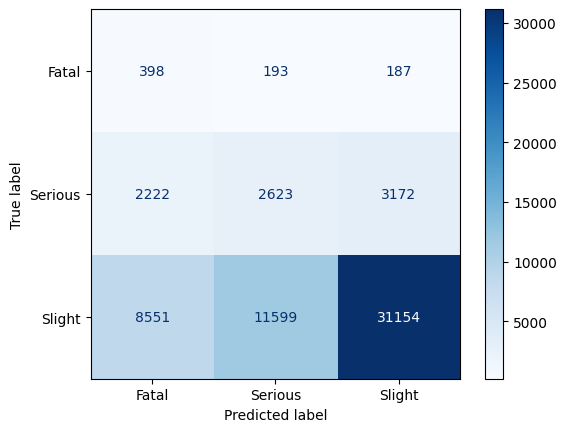

In [19]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(cmap="Blues")
plt.show()

In [21]:
print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
))

              precision    recall  f1-score   support

       Fatal       0.04      0.51      0.07       778
     Serious       0.18      0.33      0.23      8017
      Slight       0.90      0.61      0.73     51304

    accuracy                           0.57     60099
   macro avg       0.37      0.48      0.34     60099
weighted avg       0.80      0.57      0.65     60099

